In [1]:
import sqlite3
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
conn = sqlite3.connect(r"D:\machine learining project 2\data\inventory.db")

In [3]:
tables = pd.read_sql_query("select name from sqlite_master where type= 'table'",conn)

In [4]:
for table in tables['name']: 
    print('Table name is',  table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)

Table name is purchases
Table name is purchase_prices
Table name is vendor_invoice
Table name is begin_inventory
Table name is end_inventory


In [5]:
purchase_agg_df = pd.read_sql_query("""
select
p.PONumber, 
count(distinct p.Brand) as total_brands, 
sum(p.Quantity) as total_item_quantity, 
sum(p.Dollars) as total_item_dollars,
avg(julianday(ReceivingDate)- julianday(PODate)) as avg_receiving_delay
from purchases p 
group by p.PONumber
""",conn)

In [6]:
pd.read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity, 
vi.Dollars as invoice_dollars, 
vi.Freight, 
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice, 
(julianday(vi.PayDate)- julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""", conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [7]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(ReceivingDate) - julianday(PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay
FROM vendor_invoice vi
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber
""", conn)

print(df.columns.tolist())

['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']


In [8]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [9]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [10]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [11]:
def create_invoice_risk_label(row): 

    #Invoice total mismatch with item-level total 
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5): 
        return 1

    #Abnormally high receving delay 
    if row["avg_receiving_delay"] > 10: 
        return 1 

    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1) 
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

In [12]:
df.columns


Index(['PONumber', 'invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay',
       'flag_invoice'],
      dtype='object')

<Axes: xlabel='flag_invoice'>

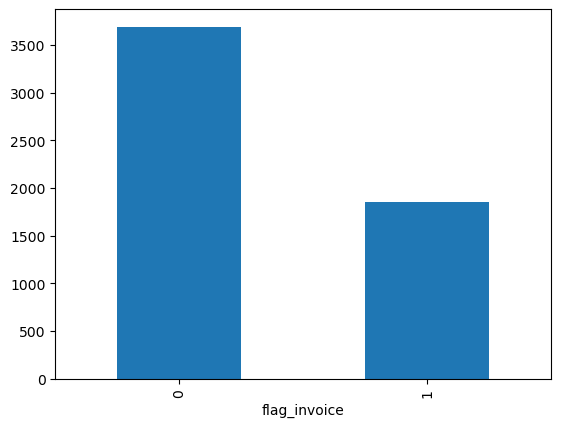

In [13]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [14]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


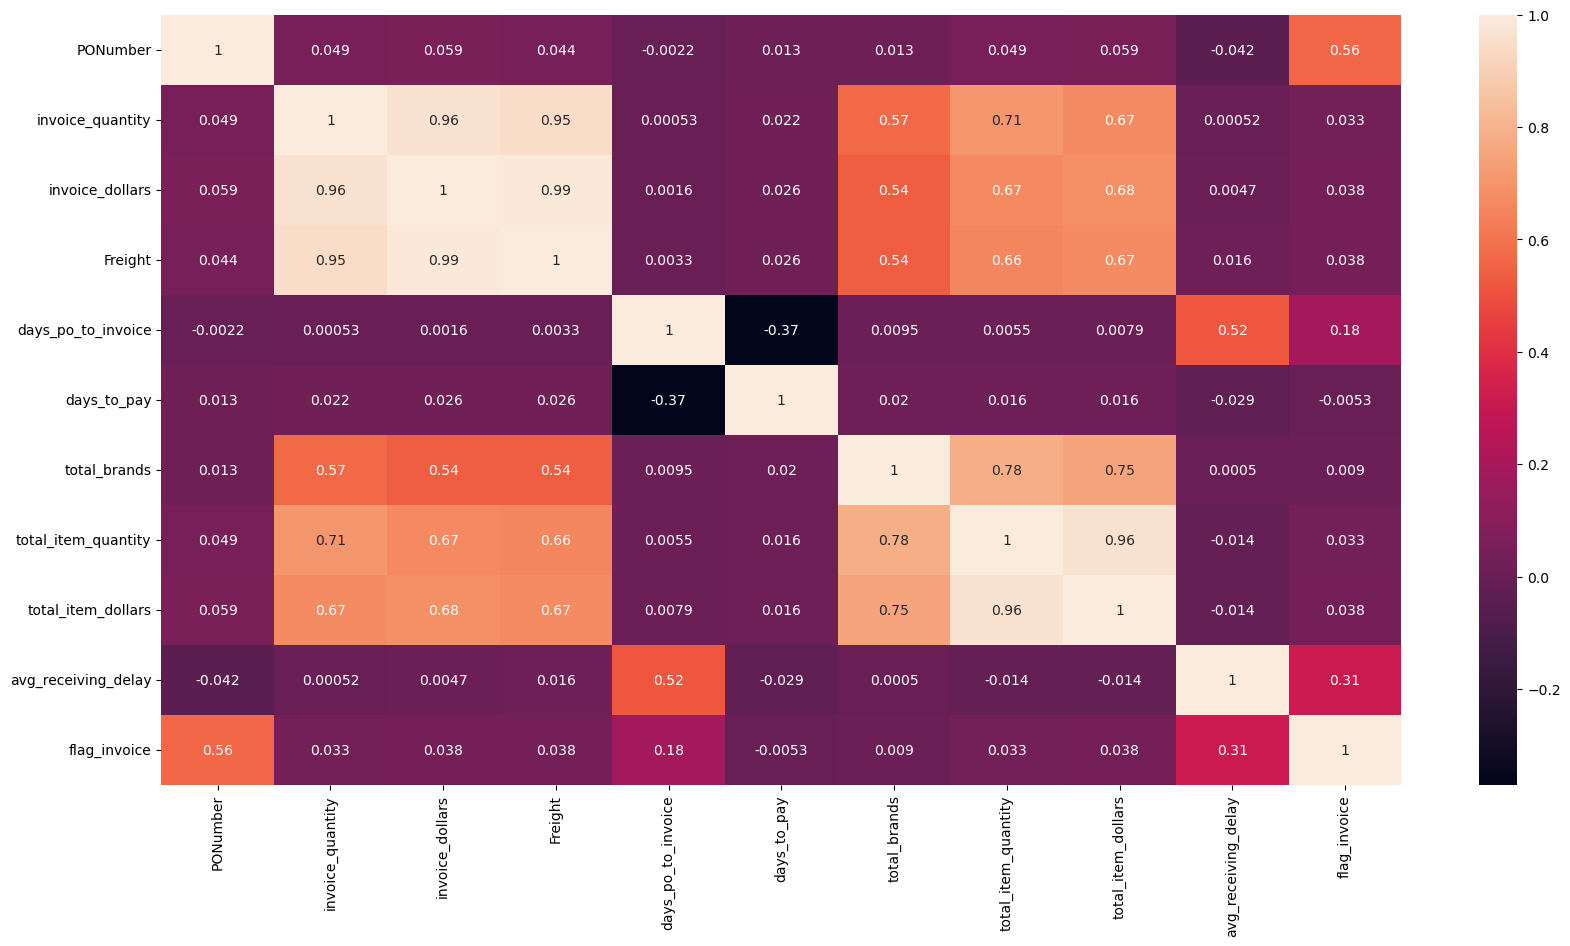

In [15]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),annot=True) 
plt.show()

In [16]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [17]:
significant_features = []
non_significant_features= []
results = []

In [18]:
from scipy.stats import ttest_ind

metrics = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'days_to_pay',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
]

significant_features = []
non_significant_features = []
results = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)

        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)

In [19]:
non_significant_features

['days_to_pay', 'total_brands']

In [20]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [21]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'invoice_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'Freight',
  'flagged_mean': 334.02,
  'normal_mean': 276.89,
  'p_value': 0.008},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': 17.23,
  'normal_mean': 16.02,
  'p_value': 0.0},
 {'metric': 'total_item_quantity',
  'flagged_mean': 6728.28,
  'normal_mean': 5723.55,
  'p_value': 0.021},
 {'metric': 'total_item_dollars',
  'flagged_mean': 65600.61,
  'normal_mean': 54302.64,
  'p_value': 0.008},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': 8.47,
  'normal_mean': 7.27,
  'p_value': 0.0}]

In [22]:
X = df[['invoice_quantity',
    'invoice_dollars',
    'Freight',
    'days_po_to_invoice',
    'total_brands',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
    ]]

In [23]:
y = df['flag_invoice']

In [24]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,41.0,6059.0,58073.0,8.0
std,14453.0,140234.0,714.0,3.0,77.0,14453.0,140234.0,2.0
min,1.0,4.0,0.0,9.0,1.0,1.0,4.0,3.0
25%,83.0,968.0,5.0,14.0,3.0,83.0,968.0,6.0
50%,423.0,4765.0,25.0,16.0,7.0,423.0,4765.0,8.0
75%,5100.0,44587.0,230.0,19.0,46.0,5100.0,44587.0,9.0
max,141660.0,1660436.0,8468.0,23.0,807.0,141660.0,1660436.0,13.0


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [28]:
model1 = LogisticRegression()
model1.fit(X_train_scaled,y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled,y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [29]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a classification model.
    """
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{'='*50}")
    print(f"{model_name}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "model_name": model_name,
        "accuracy": accuracy
    }

In [30]:
lr_results = evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
dt_results = evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
rf_results = evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression
Accuracy: 0.7394

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.93      0.82       725
           1       0.73      0.39      0.51       384

    accuracy                           0.74      1109
   macro avg       0.74      0.66      0.67      1109
weighted avg       0.74      0.74      0.71      1109

Confusion Matrix:
[[671  54]
 [235 149]]

Decision Tree Classifier
Accuracy: 0.9432

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       725
           1       0.93      0.90      0.92       384

    accuracy                           0.94      1109
   macro avg       0.94      0.93      0.94      1109
weighted avg       0.94      0.94      0.94      1109

Confusion Matrix:
[[701  24]
 [ 39 345]]

Random Forest Classifier
Accuracy: 0.9567

Classification Report:
              precision    recall  f1-score   support

           0 

In [31]:
results = [lr_results, dt_results, rf_results]

best_model = max(results, key=lambda x: x["accuracy"])

print(
    f"\nBest Model: {best_model['model_name']} "
    f"(Accuracy = {best_model['accuracy']:.4f})"
)


Best Model: Random Forest Classifier (Accuracy = 0.9567)


In [32]:
model3.feature_importances_

array([0.10781554, 0.1110527 , 0.08583862, 0.02905728, 0.05587377,
       0.14937069, 0.16583511, 0.29515628])

In [33]:
feature_importance = pd.DataFrame({
    "feature" : X_train.columns, 
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending= False) 

feature_importance

,feature,importance
7,avg_receiving_delay,0.295156
6,total_item_dollars,0.165835
5,total_item_quantity,0.149371
1,invoice_dollars,0.111053
0,invoice_quantity,0.107816
2,Freight,0.085839
4,total_brands,0.055874
3,days_po_to_invoice,0.029057


In [34]:
    
X = df[['invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_item_quantity',
    'total_item_dollars',
    'avg_receiving_delay'
    ]]

y = df['flag_invoice']


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [36]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled,y_train)

rf_results = evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Random Forest Classifier
Accuracy: 0.9666

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       725
           1       1.00      0.90      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.95      0.96      1109
weighted avg       0.97      0.97      0.97      1109

Confusion Matrix:
[[725   0]
 [ 37 347]]


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

# Random Forest model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Scoring metric
scorer = make_scorer(f1_score)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Train
grid_search.fit(X_train_scaled, y_train)

# Evaluate
evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier
Accuracy: 0.9666

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98       725
           1       1.00      0.90      0.95       384

    accuracy                           0.97      1109
   macro avg       0.98      0.95      0.96      1109
weighted avg       0.97      0.97      0.97      1109

Confusion Matrix:
[[725   0]
 [ 37 347]]


{'model_name': 'Random Forest Classifier', 'accuracy': 0.9666366095581606}

In [41]:
from sklearn.metrics import confusion_matrix
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[725,  37],
       [  0, 347]], dtype=int64)

In [42]:
confusion_matrix(model3.predict(X_test_scaled), y_test)

array([[725,  37],
       [  0, 347]], dtype=int64)

In [43]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 3,
 'n_estimators': 100}